In [26]:
# %% libraries
import pandas as pd
from numpy import abs
import numpy as np
import matplotlib.pyplot as plt

from scipy import fft

import datetime as dt
import os,sys

_FILE_DIR = os.path.abspath("")
_SRC_DIR = os.path.dirname(_FILE_DIR)
sys.path.append(_SRC_DIR)

# local imports
import fdl21.data.prototyping_metrics as pm
import fdl21.utils.time_chunking as tc
import fdl21.data.build_filterbanks as fb

# Prepare test data

In [27]:
# %% Get data

year = '2019'
month = '05'
test_cdf_file_path =_SRC_DIR+fb._OMNI_MAG_DATA_DIR+ year +'/omni_hro_1min_'+ year+month+'01_v01.cdf'

mag_df = fb.get_test_data(fname_full_path=test_cdf_file_path)
cols = ['BY_GSE']
mag_df=mag_df[cols]
mag_df

,BY_GSE
2019-05-15 00:00:00,474.4
2019-05-15 00:01:00,475.3
2019-05-15 00:02:00,473.6
2019-05-15 00:03:00,472.6
2019-05-15 00:04:00,470.5
...,...
2019-05-15 23:56:00,419.9
2019-05-15 23:57:00,417.7
2019-05-15 23:58:00,413.2
2019-05-15 23:59:00,411.5


In [28]:
# %% Prepare FT of test data for Fourier applications

cadence = dt.timedelta(seconds=60)

mag_df.sort_index(inplace=True)
mag_df.interpolate(method='index', kind='linear',limit_direction='both',inplace=True)
df_index=pd.date_range(start=mag_df.index[0], end=mag_df.index[-1], freq=cadence)

sig_fft_df = fft.rfftn(mag_df - mag_df.mean(),axes=0)

# Theoretical Frequency Response

**(Formula from [Ch. 15 of *Digital Signal Processing Textbook*](https://www.dspguide.com/CH15.PDF)**)

Frequency response of an $M$ point moving average filter. The frequency, $f$, runs between $0$ and $0.5$. For $f = 0$, use $H[f] = 1$

$$H[f] = \frac{\sin(\pi f M)}{M\sin(\pi f)}$$

In [29]:
# %% Ch. 15 Formula
def moving_avg_freq_response(f,window=dt.timedelta(minutes=3000),cadence=dt.timedelta(minutes=1)):
    n = int(window.total_seconds()/cadence.total_seconds())
    numerator = np.sin(np.pi*f*n)
    denominator = n*np.sin(np.pi*f)
    return abs(numerator/denominator)

In [30]:
data_len = mag_df.shape[0]  
freq_spectrum = np.linspace(0.0001,data_len/2,(data_len//2)+1)

# Windows1

In [31]:
window1_SM = dt.timedelta(seconds=3000)
window1_DT = dt.timedelta(seconds=18000)

In [32]:
# Build theoretical frequency response 
FR_smooth = moving_avg_freq_response(f=freq_spectrum,
                                        window=window1_SM,
                                        cadence=cadence)

In [34]:
FR_theory = moving_avg_freq_response(f=freq_spectrum,
                                        window=window1_DT,
                                        cadence=cadence)
FR_detrend = 1 - FR_theory

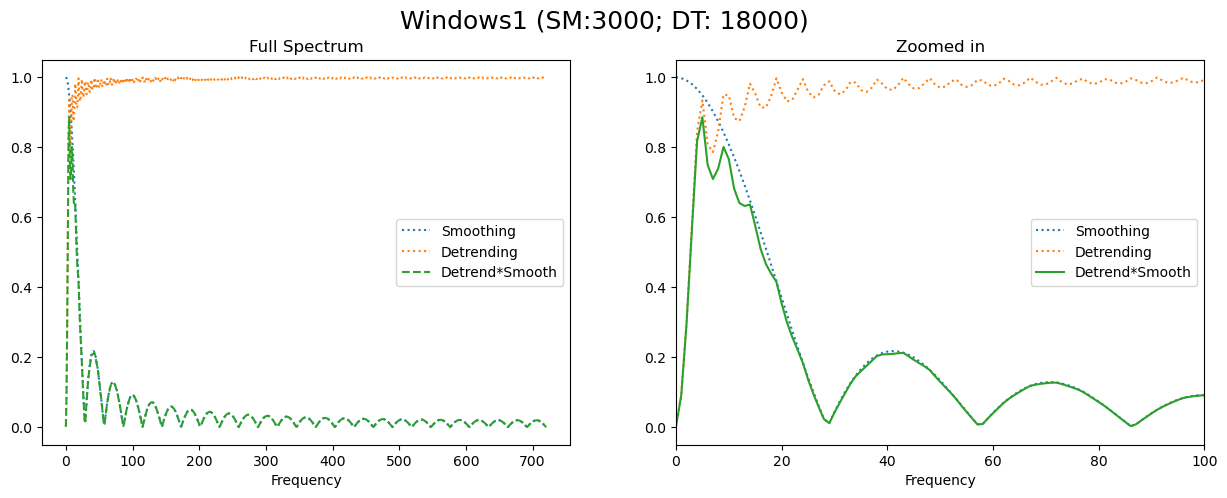

In [35]:
# plot frequency response
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(15,5))
fig.suptitle(f"Windows1 (SM:{int(window1_SM.total_seconds())}; DT: {int(window1_DT.total_seconds())})",fontsize=18)
axes[0].plot(freq_spectrum,FR_smooth,linestyle='dotted',label='Smoothing')
axes[0].plot(freq_spectrum,FR_detrend,linestyle='dotted',label='Detrending')
axes[0].plot(freq_spectrum,FR_detrend*FR_smooth,linestyle='dashed',label='Detrend*Smooth')
axes[0].set_xlabel("Frequency")
axes[0].set_title('Full Spectrum')
axes[1].plot(freq_spectrum,FR_smooth,linestyle='dotted',label='Smoothing')
axes[1].plot(freq_spectrum,FR_detrend,linestyle='dotted',label='Detrending')
axes[1].plot(freq_spectrum,FR_detrend*FR_smooth,label='Detrend*Smooth')
axes[1].set_xlim(0,100)
axes[1].set_xlabel("Frequency")
axes[1].set_title('Zoomed in')
axes[0].legend()
axes[1].legend()

# Windows2